# Analítica de Datos y Sistemas Predictivos

# Proyecto: Primeros Pasos en Machine Learning


Objetivo del Proyecto: </br>
- Analizar el caso expuesto por un dataset de Kaggle </br>
- Realizar la carga de un dataset via github </br>
- Explorar el dataset y sus principales caracteristicas </br>

## 1.1 Introduccion del caso

### Descripción de la fuente del dataset

El dataset seleccionado contiene información financiera y demográfica de clientes, con el objetivo de predecir si un cliente puede caer en morosidad. La fuente puede ser Kaggle, GitHub o un CSV propio. Para asegurar su disponibilidad en Google Colab, se cargará el archivo desde una URL pública o se subirá directamente al entorno de trabajo.

### Descripción del problema a resolver

El problema consiste en predecir si un cliente caerá en morosidad o no, usando información financiera y personal como edad, ingresos, tipo de vivienda, años de empleo, propósito del préstamo, grado del préstamo, monto solicitado, tasa de interés, porcentaje del ingreso comprometido e historial crediticio.

Las variables de entrada son las siguientes:
```
person_age: edad del cliente
person_income: ingreso anual del cliente
person_home_ownership: tipo de vivienda
person_emp_length: años de empleo
loan_intent: propósito del préstamo
loan_grade: grado/riesgo del préstamo
loan_amnt: monto del préstamo
loan_int_rate: tasa de interés
loan_percent_income: porcentaje del ingreso destinado al préstamo
cb_person_default_on_file: historial previo de incumplimiento
cb_person_cred_hist_length: años de historial crediticio
```

La variable objetivo es loan_status, donde:           
**0 representa a un cliente no moroso**              
**1 representa a un cliente moroso**


Por lo tanto, se trata de un problema de aprendizaje supervisado por clasificación binaria.









Importación de librerias necesarias

## 1.2 Desarrollo del Caso

### Importación de librerias necesarias

In [1]:
#Para esta actividad se instalarán las siguientes librerías:
%pip install pandas matplotlib numpy seaborn scikit-learn -q

You should consider upgrading via the '/Users/joss/.pyenv/versions/3.10.5/bin/python -m pip install --upgrade pip' command.
Note: you may need to restart the kernel to use updated packages.


In [2]:
#Para esta actividad se importaran las siguientes librerías:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, f1_score
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression


### Carga del Dataset

GitHub permite alojar pequeños datasets en la nube, pero algunas consideraciones importantes que se debe tener en cuenta las limitaciones de tamaño:

<ul><li>Tamaño de archivo individual: GitHub tiene límites en el tamaño de los archivos individuales que puedes subir a un repositorio. Si bien se puede subir archivos de hasta 100 MB directamente, se recibirá una advertencia al intentar subir archivos mayores a 50 MB. Para archivos más grandes, se recomienda utilizar Git Large File Storage (LFS). </li>
<li>Tamaño total del repositorio: Si bien no hay un límite estricto para el tamaño total de un repositorio, se recomienda mantener los repositorios pequeños, idealmente por debajo de 1 GB, y se recomienda encarecidamente que sean inferiores a 5 GB. Los repositorios más pequeños se clonan más rápido y son más fáciles de manejar.</li></ul>

In [3]:
#Código para cargar el Dataset

#from google.colab import files
#uploaded = files.upload()
df = pd.read_csv("https://raw.githubusercontent.com/crmenddez/Credit_Risk_Dataset/refs/heads/main/credit_risk_dataset.csv")

#Revisión de resultados
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


### Caracterización del Dataset

Antes de empezar a trabajar con un dataset para la creación de modelos de machine learning es necesario analizar algunas de sus caracteristicas, por ejemplo:

>- Número de instancias en total.
>- Número de atributos de entrada, su significado y tipo.
>- Estadísticas de la variable objetivo.
>- Estadísticas los atributos en relación con la variable objetivo.

El análisis puede realizarse mediante tablas o en modo gráfico (p.ej., histogramas, diagramas de dispersión, diagramas de cajas y bigotes, etc.)

In [4]:
#Revisión de tipo de datos de las variables de entrada y objetivo
df.info()
print()

#Evaluando dimensión del dataset (numero de filas y columnas) con la funcion shape
print("El dataset tiene", df.shape[0], "registros y", df.shape[1], "columnas.")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32581 entries, 0 to 32580
Data columns (total 12 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   person_age                  32581 non-null  int64  
 1   person_income               32581 non-null  int64  
 2   person_home_ownership       32581 non-null  object 
 3   person_emp_length           31686 non-null  float64
 4   loan_intent                 32581 non-null  object 
 5   loan_grade                  32581 non-null  object 
 6   loan_amnt                   32581 non-null  int64  
 7   loan_int_rate               29465 non-null  float64
 8   loan_status                 32581 non-null  int64  
 9   loan_percent_income         32581 non-null  float64
 10  cb_person_default_on_file   32581 non-null  object 
 11  cb_person_cred_hist_length  32581 non-null  int64  
dtypes: float64(3), int64(5), object(4)
memory usage: 3.0+ MB

El dataset tiene 32581 registr

In [5]:
#Análisis de campos nulos
conteo_null = df.isnull().sum()
print("Numero de valores nulos por columna: ")
print(conteo_null)

Numero de valores nulos por columna: 
person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64


In [6]:
#Análisis de variables de entrada (numericos)
dfnum = df.drop(['loan_status'], axis=1)
dfnum.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,0.830000,30.000000


Ahora analicemos los outliers mediante un grafico de cajas y bigotes. Recordemos conceptos básicos del gráfico.

<Figure size 1500x1000 with 0 Axes>

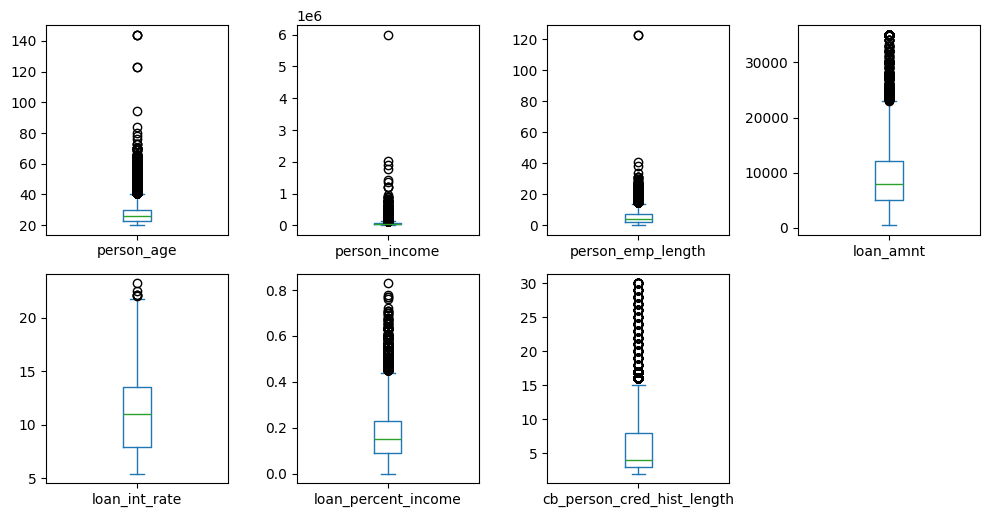

In [7]:
#Se visualiza la distribución de datos numéricos mediante un grafico de cajas y velas para cada variable numerica
# Ajustamos el tamaño de cada figura
plt.figure(figsize=(15, 10))

#Se crea un grupo de graficos de cajas y velas
dfnum.plot(kind='box', subplots=True, layout=(4, 4),figsize=(10, 10), sharex=False, sharey=False)

#Se ajusta el formato de ejes para cada subgrafico
for ax in plt.gcf().axes:
    ax.set_xlabel(ax.get_xlabel(), fontsize=14)
    ax.set_ylabel(ax.get_ylabel(), fontsize=14)

#Se ajusta el diseño de los subplots
plt.tight_layout()

#Se muestra el gráfico
plt.show()

In [8]:

# Seleccionar solo columnas numéricas
dfnum = df.select_dtypes(include=['int64', 'float64']).drop("loan_status", axis=1)
# Función para calcular el porcentaje de outliers para cada variable numérica
def calcular_porcentaje_outliers(col):
    Q1 = col.quantile(0.25)
    Q3 = col.quantile(0.75)
    IQR = Q3 - Q1

    # Definimos los límites para considerar un valor como outlier
    outliers = col[(col < Q1 - 1.5 * IQR) | (col > Q3 + 1.5 * IQR)]

    porcentaje = len(outliers) / len(col) * 100
    return porcentaje

# Aplicar la función a todas las columnas y almacenar los resultados
porcentajes_outliers = {}
for columna in dfnum.columns:
    porcentajes_outliers[columna] = calcular_porcentaje_outliers(dfnum[columna])

# Imprimir los resultados
for columna, porcentaje in porcentajes_outliers.items():
    print(f"La columna '{columna}' tiene un {porcentaje:.2f}% de outliers.")

La columna 'person_age' tiene un 4.59% de outliers.
La columna 'person_income' tiene un 4.55% de outliers.
La columna 'person_emp_length' tiene un 2.62% de outliers.
La columna 'loan_amnt' tiene un 5.18% de outliers.
La columna 'loan_int_rate' tiene un 0.02% de outliers.
La columna 'loan_percent_income' tiene un 2.00% de outliers.
La columna 'cb_person_cred_hist_length' tiene un 3.51% de outliers.


Numero de clientes pertenecientes a cada clase de la variable objetivo:

loan_status
0    25473
1     7108
dtype: int64



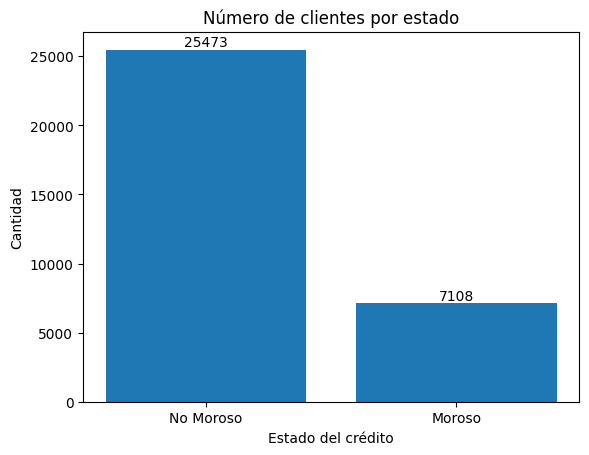

In [9]:
#Análisis de variable objetivo
print("Numero de clientes pertenecientes a cada clase de la variable objetivo:")
print()
print(df.groupby('loan_status').size())
print()

#Imprimiendo el numero de instancias pertenecientes a cada clase de la variable objetivo en un grafico de barras
#Uso de value_counts() para contar los valores de cada clase
conteoclases = df["loan_status"].value_counts()
# Crear un diccionario para mapear los valores numéricos a las letras
mapping = {0: 'No Moroso', 1: 'Moroso'}
#Uso de pltbar() para ingresar indices(etiquetas de clase) y valores(conteo) de conteoclases
plt.bar(conteoclases.index , conteoclases.values)
#Posiciona las etiquetas ligeramente por encima de las barras y con un pequeño offset hacia la izquierda
for i in range(len(conteoclases.index)):
    plt.text(conteoclases.index[i], conteoclases.values[i] + 50, conteoclases.values[i], ha='center', va='bottom', fontsize=10)
#Personalización del gráfico
plt.title("Número de clientes por estado")
plt.xlabel("Estado del crédito")
plt.ylabel("Cantidad")
plt.xticks(conteoclases.index)
#plt.ylim(0, 200)  # Ajusta el límite superior del eje y
# Cambiar las etiquetas del eje x por las letras correspondientes
plt.xticks(conteoclases.index, conteoclases.index.map(mapping))
plt.show()

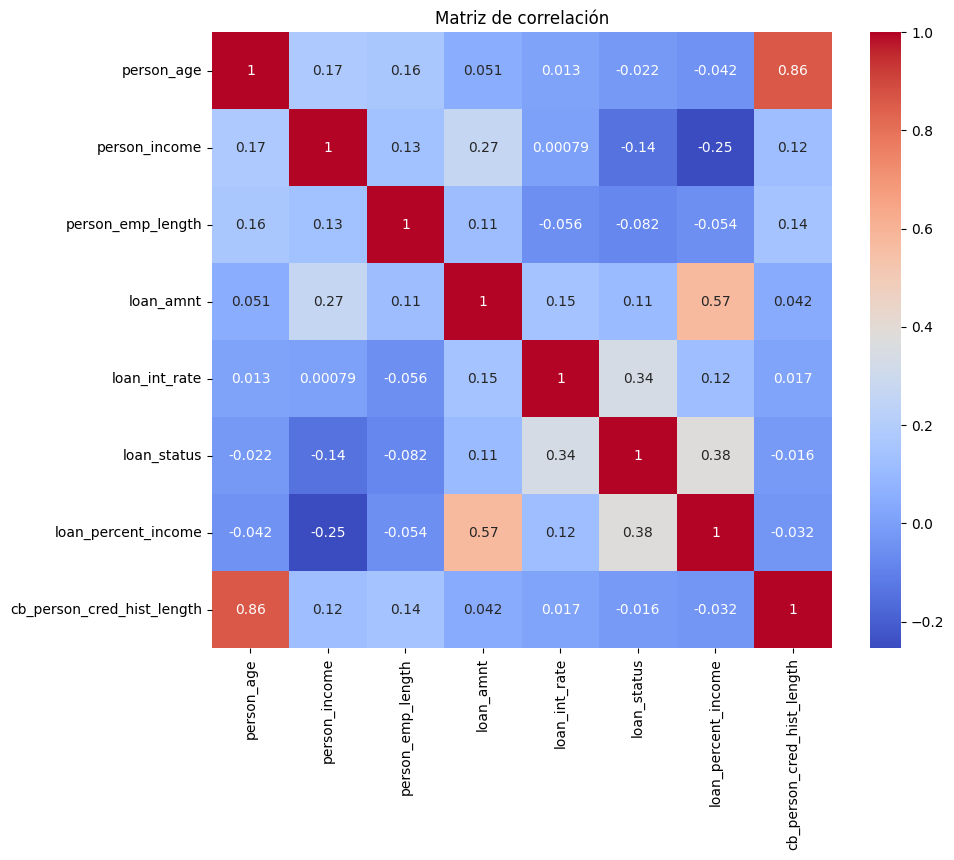

In [10]:
#Matriz de correlación de variables
df_numeric = df.select_dtypes(include=[np.number])
correlation_matrix = df_numeric.corr()
plt.figure(figsize=(10,8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm')
plt.title('Matriz de correlación')
plt.show()

### Conclusiones del análisis exploratorio




Se identificaron valores atípicos (outliers) en las variables numéricas del dataset. La mayoría de variables presenta un porcentaje bajo de outliers (entre 2% y 5%), lo cual es común en datos financieros reales.

Sin embargo, la variable objetivo loan_status no fue considerada en este análisis, ya que es una variable categórica binaria y no corresponde aplicar técnicas de detección de outliers sobre ella.

## 1.3 Preprocesamiento del dataset




In [11]:
#Elimina filas que tienen valores nulos
df = df.dropna()
#Convertir texto a números
df = pd.get_dummies(df, drop_first=True)
# Separar características y variable objetivo
X = df.drop("loan_status", axis=1)
Y = df["loan_status"]
# Normalización de variables de entrada
Xesc = MinMaxScaler().fit_transform(X)
# Dividir los datos en entrenamiento y prueba
x_tr, x_te, y_tr, y_te = train_test_split(
    Xesc, Y, test_size=0.2, random_state=42
)

In [12]:
# Crear el modelo 1 - Multinominal Naive Bayes
modeloNB = MultinomialNB()
modeloNB.fit(x_tr, y_tr)

# Hacer predicciones y evaluar el modelo
y_pred_NB = modeloNB.predict(x_te)

In [13]:
# Crear el modelo 2 - Support Vector Classifier
modelSVC = SVC(kernel='linear')
modelSVC.fit(x_tr, y_tr)

# Hacer predicciones y evaluar el modelo
y_pred_SVC = modelSVC.predict(x_te)

In [14]:
# Crear el modelo 3 - Decision Tree Classifier
modeloDTC = DecisionTreeClassifier()
modeloDTC.fit(x_tr, y_tr)

# Hacer predicciones y evaluar el modelo
y_pred_DTC = modeloDTC.predict(x_te)

In [15]:
# Crear el modelo 4 - Random Forest Classifier
modeloRFC = RandomForestClassifier(n_estimators=100)
modeloRFC.fit(x_tr, y_tr)

# Hacer predicciones y evaluar el modelo
y_pred_RFC = modeloRFC.predict(x_te)

In [16]:
# Crear el modelo 5 - Logistic Regression
modeloLR = LogisticRegression(max_iter=1000)
modeloLR.fit(x_tr, y_tr)

y_pred_lr = modeloLR.predict(x_te)

## 1.4. Revisión de métricas de desempeño

### Calculo de metricas para regresión: Accuracy, Precision, Recall, F1-Score y Matriz de Confusión

In [17]:
#Código para mostrar la evaluación de los modelos

accuracy_NB = accuracy_score(y_te, y_pred_NB)
precision_NB = precision_score(y_te, y_pred_NB, average='weighted')
recall_NB = recall_score(y_te, y_pred_NB, average='weighted')
f1_NB =  2 * (precision_NB * recall_NB) / (precision_NB + recall_NB)


print(f" accuracy (Naive Bayes): {accuracy_NB}")
print(f" precision (Naive Bayes): {precision_NB}")
print(f" recall (Naive Bayes): {recall_NB}")
print(f" f1-score (Naive Bayes): {f1_NB}")

print()

accuracy_SVC = accuracy_score(y_te, y_pred_SVC)
precision_SVC = precision_score(y_te, y_pred_SVC, average='weighted')
recall_SVC = recall_score(y_te, y_pred_SVC, average='weighted')
f1_SVC =  2 * (precision_SVC * recall_SVC) / (precision_SVC + recall_SVC)


print(f" accuracy (Support Vector Classifier): {accuracy_SVC}")
print(f" precision (Support Vector Classifier): {precision_SVC}")
print(f" recall (Support Vector Classifier): {recall_SVC}")
print(f" f1-score (Support Vector Classifier): {f1_SVC}")

print()

accuracy_DTC = accuracy_score(y_te, y_pred_DTC)
precision_DTC = precision_score(y_te, y_pred_DTC, average='weighted')
recall_DTC = recall_score(y_te, y_pred_DTC, average='weighted')
f1_DTC =  2 * (precision_DTC * recall_DTC) / (precision_DTC + recall_DTC)


print(f" accuracy (Decision Tree Classifier): {accuracy_DTC}")
print(f" precision (Decision Tree Classifier): {precision_DTC}")
print(f" recall (Decision Tree Classifier): {recall_DTC}")
print(f" f1-score (Decision Tree Classifier): {f1_DTC}")

print()

accuracy_RFC = accuracy_score(y_te, y_pred_RFC)
precision_RFC = precision_score(y_te, y_pred_RFC, average='weighted')
recall_RFC = recall_score(y_te, y_pred_RFC, average='weighted')
f1_RFC =  2 * (precision_RFC * recall_RFC) / (precision_RFC + recall_RFC)


print(f" accuracy (Random Forest): {accuracy_RFC}")
print(f" precision (Random Forest): {precision_RFC}")
print(f" recall (Random Forest): {recall_RFC}")
print(f" f1-score (Random Forest): {f1_RFC}")

accuracy_lr = accuracy_score(y_te, y_pred_lr)
precision_lr = precision_score(y_te, y_pred_lr, average="weighted")
recall_lr = recall_score(y_te, y_pred_lr, average="weighted")
f1_lr = f1_score(y_te, y_pred_lr, average="weighted")

print()

print(f" accuracy (Logistic Regression): {accuracy_lr}")
print(f" precision (Logistic Regression): {precision_lr}")
print(f" recall (Logistic Regression): {recall_lr}")
print(f" f1-score (Logistic Regression): {f1_lr}")

 accuracy (Naive Bayes): 0.8294343575418994
 precision (Naive Bayes): 0.8174257176394294
 recall (Naive Bayes): 0.8294343575418994
 f1-score (Naive Bayes): 0.8233862550512487

 accuracy (Support Vector Classifier): 0.8634776536312849
 precision (Support Vector Classifier): 0.8566779606381364
 recall (Support Vector Classifier): 0.8634776536312849
 f1-score (Support Vector Classifier): 0.8600643677038773

 accuracy (Decision Tree Classifier): 0.890013966480447
 precision (Decision Tree Classifier): 0.891039350250151
 recall (Decision Tree Classifier): 0.890013966480447
 f1-score (Decision Tree Classifier): 0.8905263631995493

 accuracy (Random Forest): 0.9308659217877095
 precision (Random Forest): 0.9325698558577314
 recall (Random Forest): 0.9308659217877095
 f1-score (Random Forest): 0.9317171097802256

 accuracy (Logistic Regression): 0.8613826815642458
 precision (Logistic Regression): 0.8544666854715246
 recall (Logistic Regression): 0.8613826815642458
 f1-score (Logistic Regressi

### Comparación de resultados

In [18]:
# Código para mostrar la comparación de métricas de desempeño de las cinco propuestas en tabla

# Datos de las métricas
resultadosReg = {
    'Modelo': [
        'Multinominal Naive Bayes',
        'Support Vector Classifier',
        'Decision Tree Classifier',
        'Random Forest Classifier',
        'Logistic Regression'
    ],
    'Accuracy': [
        accuracy_NB,
        accuracy_SVC,
        accuracy_DTC,
        accuracy_RFC,
        accuracy_lr
    ],
    'Precision': [
        precision_NB,
        precision_SVC,
        precision_DTC,
        precision_RFC,
        precision_lr
    ],
    'Recall': [
        recall_NB,
        recall_SVC,
        recall_DTC,
        recall_RFC,
        recall_lr
    ],
    'F1-Score': [
        f1_NB,
        f1_SVC,
        f1_DTC,
        f1_RFC,
        f1_lr
    ]
}

# Crear el DataFrame
df_res = pd.DataFrame(resultadosReg)

# Mostrar la tabla
df_res.head()

,Modelo,Accuracy,Precision,Recall,F1-Score
0,Multinominal Naive Bayes,0.829434,0.817426,0.829434,0.823386
1,Support Vector Classifier,0.863478,0.856678,0.863478,0.860064
2,Decision Tree Classifier,0.890014,0.891039,0.890014,0.890526
3,Random Forest Classifier,0.930866,0.932570,0.930866,0.931717
4,Logistic Regression,0.861383,0.854467,0.861383,0.851531


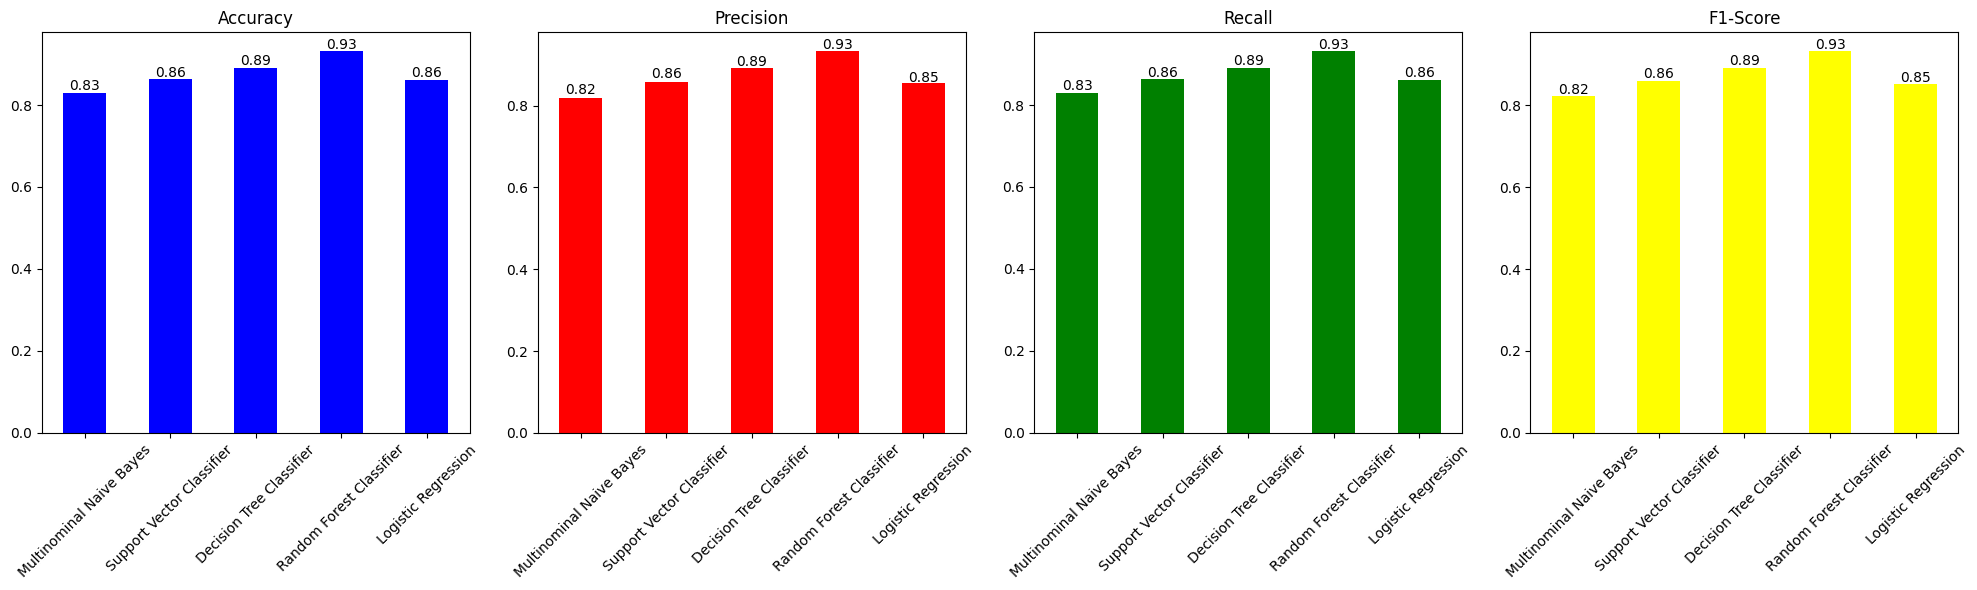

In [19]:
fig, axes = plt.subplots(nrows=1, ncols=4, figsize=(20, 6))

# Accuracy
df_res.plot(x='Modelo', y='Accuracy', kind='bar', ax=axes[0], title='Accuracy', color='blue', legend=False)
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=45)
for p in axes[0].patches:
    height = round(p.get_height(), 2)
    axes[0].annotate(str(height), (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

# Precision
df_res.plot(x='Modelo', y='Precision', kind='bar', ax=axes[1], title='Precision', color='red', legend=False)
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=45)
for p in axes[1].patches:
    height = round(p.get_height(), 2)
    axes[1].annotate(str(height), (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

# Recall
df_res.plot(x='Modelo', y='Recall', kind='bar', ax=axes[2], title='Recall', color='green', legend=False)
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=45)
for p in axes[2].patches:
    height = round(p.get_height(), 2)
    axes[2].annotate(str(height), (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

# F1-Score
df_res.plot(x='Modelo', y='F1-Score', kind='bar', ax=axes[3], title='F1-Score', color='yellow', legend=False)
axes[3].set_xlabel('')
axes[3].tick_params(axis='x', rotation=45)
for p in axes[3].patches:
    height = round(p.get_height(), 2)
    axes[3].annotate(str(height), (p.get_x() + p.get_width() / 2., height), ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

## 1.5. Conclusiones sobre los modelos creados:

De acuerdo con los resultados obtenidos, todos los modelos presentan un buen desempeño en la clasificación de morosidad, con valores superiores a 0.80 en la mayoría de las métricas evaluadas.

El modelo **Random Forest Classifier** destaca como el mejor, alcanzando los valores más altos en Accuracy, Precision, Recall y F1-Score (≈ 0.93), lo que indica una alta capacidad para predecir correctamente tanto clientes morosos como no morosos.

Los modelos **Decision Tree Classifier, Support Vector Classifier y Logistic Regression** también muestran un desempeño sólido, con resultados cercanos al modelo líder, siendo alternativas viables.

Por otro lado, el modelo **Multinomial Naive Bayes**, aunque presenta el menor rendimiento relativo, aún mantiene métricas aceptables, lo que indica que todos los modelos logran una buena capacidad predictiva en este dataset.

En conclusión, se recomienda el uso de Random Forest para este problema, debido a su mayor precisión y equilibrio entre las métricas evaluadas.